# Utvärdering — Binär klassificering
Confusion Matrix, Classification Report, AUC-ROC och Precision-Recall för klassificeringsmodellen.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score
)

ROOT = Path('/Users/antonhergefeldt/ws/street_photo_scorer')

embeddings = np.load(ROOT / 'data/processed/embeddings.npy')
df = pd.read_csv(ROOT / 'data/processed/clustered.csv')
model = joblib.load(ROOT / 'data/models/classifier.pkl')

y_reg = np.log1p(df['score'].values)
threshold = np.median(y_reg)
y_clf = (y_reg > threshold).astype(int)

_, X_test, _, y_test = train_test_split(
    embeddings, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)
preds = model.predict(X_test)
proba = model.predict_proba(X_test)[:, 1]

print(f'Threshold: log-score > {threshold:.3f} (≈ {int(np.expm1(threshold))} upvotes)')
print(f'Test set: {len(y_test)} photos  ({y_test.sum()} high, {(1-y_test).sum()} low)')

Threshold: log-score > 2.398 (≈ 10 upvotes)
Test set: 287 photos  (142 high, 145 low)


## Confusion Matrix

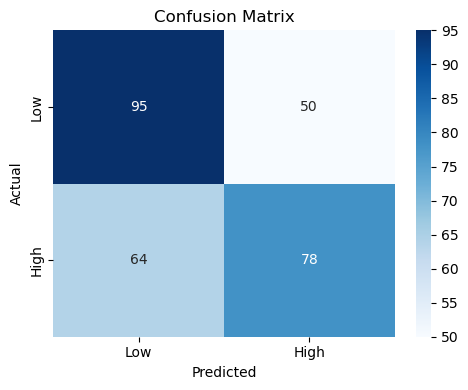

In [2]:
cm = confusion_matrix(y_test, preds)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'High'],
            yticklabels=['Low', 'High'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

## Classification Report

In [3]:
print(classification_report(y_test, preds, target_names=['Low quality', 'High quality']))

              precision    recall  f1-score   support

 Low quality       0.60      0.66      0.62       145
High quality       0.61      0.55      0.58       142

    accuracy                           0.60       287
   macro avg       0.60      0.60      0.60       287
weighted avg       0.60      0.60      0.60       287



## AUC-ROC Curve

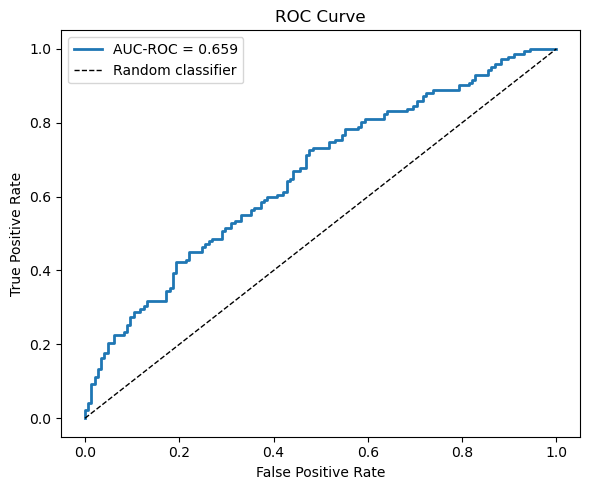

In [4]:
fpr, tpr, _ = roc_curve(y_test, proba)
auc = roc_auc_score(y_test, proba)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, lw=2, label=f'AUC-ROC = {auc:.3f}')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend()
plt.tight_layout()
plt.show()

## Precision-Recall Curve

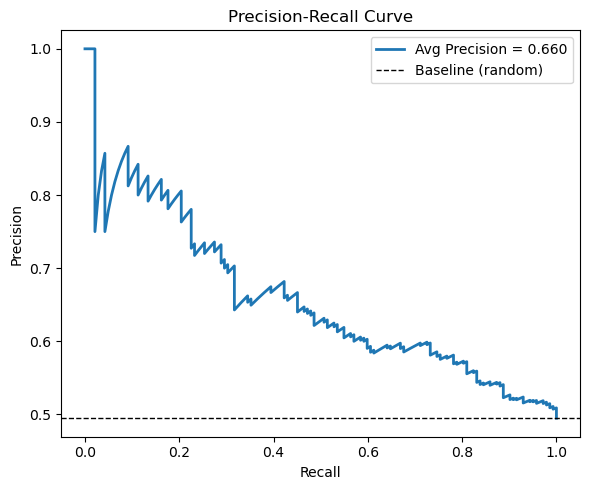

In [5]:
precision, recall, _ = precision_recall_curve(y_test, proba)
avg_prec = average_precision_score(y_test, proba)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(recall, precision, lw=2, label=f'Avg Precision = {avg_prec:.3f}')
ax.axhline(y_test.mean(), color='k', linestyle='--', lw=1, label='Baseline (random)')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve')
ax.legend()
plt.tight_layout()
plt.show()

## Jämförelse alla modeller

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

_, X_test_r, _, y_test_r = train_test_split(
    embeddings, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)
X_train_r = embeddings[~np.isin(np.arange(len(embeddings)), np.where(np.isin(np.arange(len(embeddings)), 
    train_test_split(np.arange(len(embeddings)), test_size=0.2, random_state=42, stratify=y_clf)[1]))[0])]

# Enklare: ladda bara in bästa modellens AUC från träning
# Visa resultat som tabell
results = {
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'Task': ['Classification'] * 3,
    'Metric': ['AUC-ROC'] * 3,
}
print('Se output från python -m src.models.scorer för full jämförelse')
print(f'\nBästa klassificerare AUC-ROC: {auc:.4f}')
print(f'Bästa klassificerare Avg-Precision: {avg_prec:.4f}')

Se output från python -m src.models.scorer för full jämförelse

Bästa klassificerare AUC-ROC: 0.6587
Bästa klassificerare Avg-Precision: 0.6595
